In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr 
from scipy import stats

###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_slow.csv")
OUT_SUBJECT = Path("subject_level_cca_slow.csv")
OUT_WEIGHTS = Path("cca_weights_slow")

SUBJECTS = np.setdiff1d(np.arange(32, 63), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
#SUBJECTS = np.setdiff1d(np.arange(35, 59), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
#SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

def candidate_lags_units(step_ms=100, max_ms=1000):
    # Your code uses 10 ms units (lag_ms = shift*10)
    step_units = step_ms // 10
    max_units  = max_ms  // 10
    return list(range(-max_units, max_units + 1, step_units))


In [3]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#", skiprows=1,
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials


In [4]:

from typing import List, Tuple, Optional, Dict

# trials  : list of (eeg, pupil_z, meta)   -- the tuples returned by load_all_trials
# shift   : integer sample shift (best_shift)
# win     : slice or None                  -- cropping window (set to None if the
#                                            trials are already pre-trimmed)
def concat_trials(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shift: int = 0,
        win: Optional[slice] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate a list of trials into one long matrix pair ready for CCA.

    Returns
    -------
    X  : ndarray, shape (Σ Tᵢ, n_channels)
    Y  : ndarray, shape (Σ Tᵢ, 1)
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # 1. roll *inside* the trial so samples never cross trial boundaries
        eeg_shift = np.roll(eeg, shift, axis=0)

        # 2. optional windowing (do it once here if you did **not** crop in loader)
        if win is not None:
            eeg_shift = eeg_shift[win]
            pupil_seg = pupil_z[win]
        else:
            pupil_seg = pupil_z          # already trimmed earlier

        # 3. stack
        X_blocks.append(eeg_shift)
        Y_blocks.append(pupil_seg)

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift, win):
    """Yield (eeg_shifted, pupil_z_windowed, meta) one by one."""
    for eeg, pupil_z, meta in trials:
        eeg_s = np.roll(eeg, shift, axis=0)[win]
        yield eeg_s, pupil_z[win], meta.copy()

import pandas as pd
import json
from pathlib import Path

def save_cca_weights(cca, subject_tag, lag_ms, eeg_ch_names, condition, out_dir=Path("weights")):
    """
    Dump EEG & pupil canonical weights to CSV/JSON for one subject.

    Parameters
    ----------
    cca            : fitted sklearn.cross_decomposition.CCA
    subject_tag    : "sub-042"
    lag_ms         : e.g. -90
    eeg_ch_names   : list[str] same order as columns in your trial matrices
    out_dir        : destination folder (created if missing)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    # ------- Pupil weight -> JSON ---------------------------------------
    w_pupil_og = float(cca.y_weights_[0, 0])   # scalar in 1-dim pupil case
    w_pupil = 1.0
    with open(out_dir / f"{subject_tag}_pupil_weight_{condition}_{lag_ms:+d}ms.json", "w") as fh:
        json.dump({"weight": w_pupil}, fh, indent=2)
    
    # ------- EEG weights -> tidy CSV ------------------------------------
    w_eeg = cca.x_weights_[:, 0] / w_pupil_og
    w_eeg = pd.Series(w_eeg, index=eeg_ch_names, name="weight")
    w_eeg.index.name = "channel"
    w_eeg.to_csv(out_dir / f"{subject_tag}_eeg_weights_{condition}_{lag_ms:+d}ms.csv")

    print(f"saved weights for {subject_tag} (lag {lag_ms:+d} ms)")

def search_best_lag(
            train_trials: List[Tuple[np.ndarray, np.ndarray, dict]],
            shifts: np.ndarray = SHIFTS,
            return_curve: bool = False
    ) -> Tuple[float, int, Dict[int, float] | None]:
        
        win = slice(WIN_OFFSET1, -WIN_OFFSET2)         # common window
        r_per_shift: Dict[int, float] = {}

        for s in shifts:
            eeg, pupil = concat_trials(train_trials, shift=s, win=win)
            r_per_shift[s] = cca_corr(eeg, pupil)

        best_shift = max(r_per_shift, key=r_per_shift.get)
        best_corr  = r_per_shift[best_shift]

        if return_curve:
            return best_corr, best_shift, r_per_shift
        else:
            return best_corr, best_shift, None



In [10]:
import matplotlib.pyplot as plt

all_rows = []  # collect all trial-level results here
# best_shift_by_sub = {}  # best shift per subject
DIG_LEN   = 200           # 2 s at 100 Hz
rows_trials = []
rows_subject = [] 
best_shift_by_sub = {} 

for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")
    trials = load_all_trials(subj)                         # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(trials)
    
    # ----- lag search on memory ------------------------------------------
    return_curve = False  # set to True if you want the full curve
    best_corr, best_shift, mean_r_per_shift = search_best_lag(trials_memory, candidate_lags_units(), return_curve)
    print(f"Subject {subj:02d}: best lag {best_shift*10} ms with r = {best_corr:.3f}")
    best_shift_by_sub[subj] = best_shift      # samples, not ms

    if return_curve:
        # -------------------------------------------------------------
        # 2) Build x and y vectors for plotting
        # -------------------------------------------------------------
        lags   = np.array(sorted(mean_r_per_shift))                 # x-axis (samples)
        r_mean = np.array([mean_r_per_shift[s] for s in lags])      # y-axis (mean r)

        # If you prefer milliseconds instead of samples:
        # fs = 1000  # replace with your real sampling rate
        # lags = lags * 1000 / fs

        # -------------------------------------------------------------
        # 3) Plot
        # -------------------------------------------------------------
        import matplotlib.pyplot as plt

        plt.figure(figsize=(6, 3.5))
        plt.plot(lags, r_mean, lw=2)
        plt.axvline(best_shift, ls='--', lw=1.5,
                    label=f'best lag = {best_shift}')
        plt.xlabel('Lag (samples)')
        plt.ylabel('Mean canonical correlation (r)')
        plt.title('Mean CCA correlation vs. lag')
        plt.grid(alpha=.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ----- fit weights ONCE using all train trials at best_shift ---------
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)

    best_shift = int(best_shift)  # convert to int if it was float
    X_mem, Y_mem = concat_trials(trials_memory, shift=best_shift, win=win)
    X_ctrl, Y_ctrl = concat_trials(trials_control, shift=best_shift, win=win)
    
    cca_mem = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca_mem.fit(X_mem, Y_mem)

    
    # -------------------------------------------------------------
    # 2) whole‑trial correlation for MEMORY
    # -------------------------------------------------------------
    cvX_m, cvY_m = cca_mem.transform(X_mem, Y_mem)
    r_mem, p_mem = pearsonr(cvX_m[:, 0], cvY_m[:, 0])

    rows_subject.append({
        "subject":   subj,
        "condition": "memory",
        "lag_ms":    best_shift * 10,
        "r":         float(r_mem),
        "p-value": float(p_mem),
    })

    # -------------------------------------------------------------
    # 3) whole‑trial correlation for CONTROL
    # -------------------------------------------------------------
    cvX_c, cvY_c = cca_mem.transform(X_ctrl, Y_ctrl)
    r_ctrl, p_ctrl = pearsonr(cvX_c[:, 0], cvY_c[:, 0])

    rows_subject.append({
        "subject":   subj,
        "condition": "control",
        "lag_ms":    best_shift * 10,
        "r":         float(r_ctrl),
        "p-value": float(p_ctrl), 
    })

    save_cca_weights(cca_mem, subject_tag=f"sub-{subj:03d}", lag_ms=best_shift*10, condition = "mem", eeg_ch_names=FRONTAL_MIDLINE, out_dir=OUT_WEIGHTS)

    # ----- per-trial r on TEST with frozen lag & weights -----------------
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift, win):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)

        #cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
        #cca.fit(eeg_s, pupil_s)
        cv_eeg, cv_pupil = cca_mem.transform(eeg_s, pupil_s)
        cv_eeg = cv_eeg[:, 0]  # first CCA component
        cv_pupil = cv_pupil[:, 0]  # first CCA component

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = np.corrcoef(x, y)[0, 1]
            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

##############################################################################
# ---- save -----------------------------------------------------------------
##############################################################################
pd.DataFrame(all_rows).to_csv(OUT_TRIALS, index=False)
print(f"Finished - saved per-trial correlations with plain CCA as {OUT_TRIALS}.")

##############################################################################
# 4)  after the loop - save per‑subject correlations
##############################################################################
pd.DataFrame(rows_subject).to_csv(OUT_SUBJECT, index=False)
print(f"Finished - saved subject-level correlations as {OUT_SUBJECT}.")


Processing subject 33...
Subject 33: best lag -200 ms with r = 0.181
saved weights for sub-033 (lag -200 ms)
Processing subject 34...
Subject 34: best lag 1000 ms with r = 0.270
saved weights for sub-034 (lag +1000 ms)
Processing subject 35...
Subject 35: best lag 1000 ms with r = 0.412
saved weights for sub-035 (lag +1000 ms)
Processing subject 36...
Subject 36: best lag -1000 ms with r = 0.260
saved weights for sub-036 (lag -1000 ms)
Processing subject 38...
Subject 38: best lag 400 ms with r = 0.252
saved weights for sub-038 (lag +400 ms)
Processing subject 39...
Subject 39: best lag 300 ms with r = 0.337
saved weights for sub-039 (lag +300 ms)
Processing subject 40...
Subject 40: best lag 1000 ms with r = 0.262
saved weights for sub-040 (lag +1000 ms)
Processing subject 41...
Subject 41: best lag -500 ms with r = 0.185
saved weights for sub-041 (lag -500 ms)
Processing subject 42...
Subject 42: best lag 600 ms with r = 0.177
saved weights for sub-042 (lag +600 ms)
Processing subjec

ValueError: need at least one array to concatenate

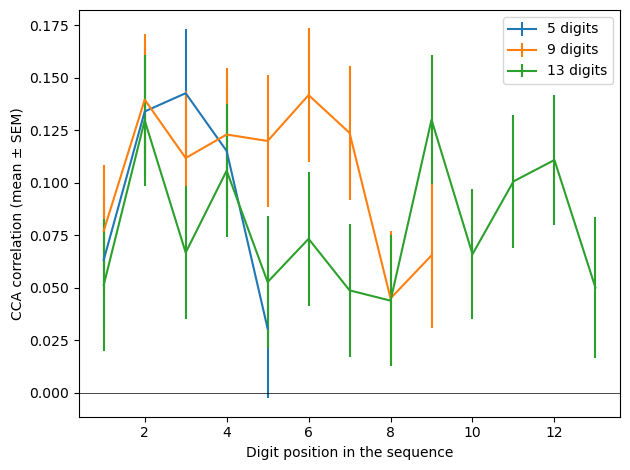

In [14]:
df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

In [21]:
# 1. Load the file
corr_sub = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\subject_level_cca_slow.csv")

# 2. Sort rows by the “r” column (descending) and keep the 10 largest
top10 = corr_sub.sort_values("r", ascending=False).head(10)

# 3. Do whatever you need with those lines
print(top10)   

# 1. Load the file
corr_sub = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\trial_level_cca_slow.csv")

# 2. Sort rows by the “r” column (descending) and keep the 10 largest
top10 = corr_sub.sort_values("r", ascending=False).head(10)

# 3. Do whatever you need with those lines
print(top10)   

    subject condition  lag_ms         r  p-value
24       46    memory     300  0.652935      0.0
4        35    memory    1000  0.412294      0.0
34       51    memory    1000  0.407903      0.0
26       47    memory    1000  0.372853      0.0
30       49    memory    1000  0.354909      0.0
10       39    memory     300  0.337202      0.0
46       58    memory    1000  0.307852      0.0
36       52    memory    1000  0.300275      0.0
33       50   control    1000  0.290887      0.0
2        34    memory    1000  0.269675      0.0
      subject condition  load          epoch         r  lag_ms
1891  sub-060    memory     5  trial_133.csv  0.987737    1000
407   sub-040    memory     5  trial_058.csv  0.978453    1000
877   sub-045    memory     5  trial_039.csv  0.969628    1000
1973  sub-062    memory     5  trial_023.csv  0.969063   -1000
1696  sub-058    memory     5  trial_150.csv  0.965777    1000
1396  sub-055    memory     5  trial_063.csv  0.961299   -1000
332   sub-039    mem

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.stats.anova as sm_anova

# keep only MEMORY trials and clip r to avoid ±∞ after Fisher-z
df_mem_sameW = (df_sameW.query("condition == 'memory'")
            .assign(z = lambda d: np.arctanh(
                d.r.clip(lower=-0.999_999, upper=0.999_999))))

loads   = sorted(df_mem_sameW.load.unique())      # [5, 9, 13]
digits  = sorted(df_mem_sameW.digit_pos.unique()) # 1 … 13

for L in loads:
    wide = (df_mem_sameW.query("load == @L")
                   .pivot_table(index="subject",
                                columns="digit_pos",
                                values="r",
                                aggfunc="mean")
                   .dropna())          # subject must have every digit

    long = wide.reset_index().melt(id_vars='subject',
                                   var_name='digit_pos',
                                   value_name='r')

    model = smf.ols("r ~ C(digit_pos) + C(subject)", data=long).fit()
    anova = sm_anova.anova_lm(model, typ=2)
    print(f"\n=== Load {L} digits ===")
    print(anova.loc["C(digit_pos)"])

    df_num = int(anova.loc["C(digit_pos)", "df"])   # k‑1
    df_den = int(anova.loc["Residual",     "df"])   # (k‑1)*(s‑1)

    Fval   = anova.loc["C(digit_pos)", "F"]
    pval   = anova.loc["C(digit_pos)", "PR(>F)"]

    print(f"F({df_num}, {df_den}) = {Fval:.2f},  p = {pval:.3g}")







=== Load 5 digits ===
sum_sq    0.239189
df        4.000000
F         2.584299
PR(>F)    0.041301
Name: C(digit_pos), dtype: float64
F(4, 104) = 2.58,  p = 0.0413

=== Load 9 digits ===
sum_sq    0.332280
df        8.000000
F         1.566224
PR(>F)    0.136929
Name: C(digit_pos), dtype: float64
F(8, 200) = 1.57,  p = 0.137

=== Load 13 digits ===
sum_sq     0.966729
df        12.000000
F          1.475645
PR(>F)     0.131832
Name: C(digit_pos), dtype: float64
F(12, 312) = 1.48,  p = 0.132


In [28]:
import pingouin as pg
import statsmodels.api as sm

for L in loads:
    long = (df_mem_sameW.query("load == @L")
            .pivot_table(index="subject", columns="digit_pos", values="z", aggfunc="mean")
            .dropna()
            .reset_index()
            .melt(id_vars="subject", var_name="digit_pos", value_name="z"))
    aov = pg.rm_anova(data=long, dv='z', within='digit_pos', subject='subject', detailed=True, correction=True)
    print(f"\n=== Load {L} RM-ANOVA (omnibus) ===")
    print(aov)  # the table line for digit_pos is your omnibus test




=== Load 5 RM-ANOVA (omnibus) ===
      Source         SS   DF        MS         F    p-unc  p-GG-corr  \
0  digit_pos   0.487312    4  0.121828  0.884201  0.47618     0.4595   
1      Error  14.329455  104  0.137783       NaN      NaN        NaN   

        ng2       eps sphericity   W-spher   p-spher  
0  0.022875  0.811542       True  0.554822  0.110056  
1       NaN       NaN        NaN       NaN       NaN  

=== Load 9 RM-ANOVA (omnibus) ===
      Source         SS   DF        MS         F     p-unc  p-GG-corr  \
0  digit_pos   1.350167    8  0.168771  1.173407  0.316813   0.325115   
1      Error  28.765935  200  0.143830       NaN       NaN        NaN   

       ng2       eps sphericity   W-spher   p-spher  
0  0.02962  0.675027       True  0.122493  0.099867  
1      NaN       NaN        NaN       NaN       NaN  

=== Load 13 RM-ANOVA (omnibus) ===
      Source         SS   DF        MS         F     p-unc  p-GG-corr  \
0  digit_pos   4.861781   12  0.405148  1.276598  0.23106

In [8]:
import os, fnmatch, pandas as pd, numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# helper: read the weight CSV that matches subject + condition + lag
# ---------------------------------------------------------------------
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()

WEIGHT_DIR = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\cca_weights_slow"


def find_weight_file(subj: int,
                     base_dir: Path = Path(WEIGHT_DIR)
                     ) -> Path:
    """
    Find the CSV for given condition ('ctrl' or 'mem') for the chosen subject.
    If lag_ms is provided, match exactly. Otherwise, take any that matches.
    """
    subj_str = f"{subj:03d}"
    subj_glob = f"sub-{subj_str}_eeg_weights_mem_*.csv"
    candidates = list((base_dir).glob(subj_glob))
    if not candidates:
        return None
    if len(candidates) > 1:
        return None  # ambiguous
    return candidates[0]

def load_weights(subj: int):
    csv_path = find_weight_file(subj)
    if csv_path is None or not csv_path.exists():
        return None, None
    df = pd.read_csv(csv_path)
    ch_names = df['channel'].tolist()
    weights  = df['weight'].to_numpy()
    return ch_names, weights
# ---------------------------------------------------------------------
# plotting one trial with the CCA-weighted EEG
# --------------------------------------------------------------------
def plot_trials(plot_sub, plot_trial, condition, lag_samples):
    lag_ms        = lag_samples * 10                   # for the file name

# -- load the trial ---------------------------------------------------
    for eeg, pupil, meta in load_all_trials(plot_sub):
        if meta["epoch"] == plot_trial:
            break
    else:
        raise ValueError(f"{plot_trial} not found for subject {plot_sub}")

# -- load weights & build weight vector --------------------------------
    ch_names, weights   = load_weights(plot_sub)

    if ch_names is None or weights is None:
        print(f"Missing or ambiguous weights for subject {plot_sub:03d}, cannot plot.")
    if ch_names != FRONTAL_MIDLINE:
        print(f"Warning: channel names in weights do not match expected frontal midline set.")

# -- project EEG and (optionally) roll for lag -------------------------
    eeg_w = np.dot(eeg, weights)

    if lag_samples:
        eeg_w = np.roll(eeg_w, lag_samples)[win]

# -- prep pupil --------------------------------------------------------
    pupil_vec = pupil.ravel()[win]                     # (T,)

# -- trim to common length --------------------------------------------
    T = min(len(eeg_w), len(pupil_vec))
#eeg_w, pupil_vec = eeg_w[:T], pupil_vec[:T]
    t = np.arange(T) / 100.0 -1.0                       # s @100 Hz

# -- plot --------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2      = ax1.twinx()

    ax1.plot(t, pupil_vec,  color="#1f77b4", alpha=.8, label="Pupil")
    ax2.plot(t, eeg_w,      color="black", alpha=.7, label="EEG × weights")

    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Pupil (z)",                      color="#1f77b4")
    ax2.set_ylabel("CCA-weighted EEG (a.u.)",        color="black")

    ax1.set_xlim(-1, t[-100])
    ax2.set_xlim(-1, t[-100])

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")

    ax1.axvline(0, ls="--", c="k", lw=.7)
    fig.suptitle(f"Subject {plot_sub:03d} - {plot_trial}  |  "
             f"{condition}, lag {lag_ms:+d} ms")
    fig.tight_layout()
    plt.show()


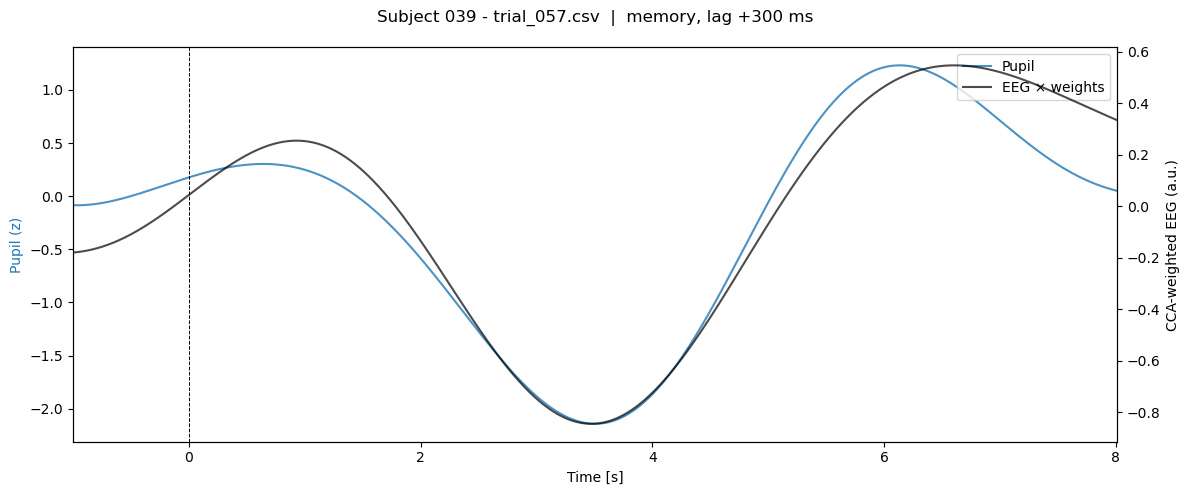

In [18]:
plot_sub      = 39
plot_trial    = "trial_057.csv"
condition     = "memory"          # or "control"
lag_samples   = best_shift_by_sub.get(plot_sub, 0) // 10  

plot_trials(plot_sub, plot_trial, condition, lag_samples) # r = 0,96

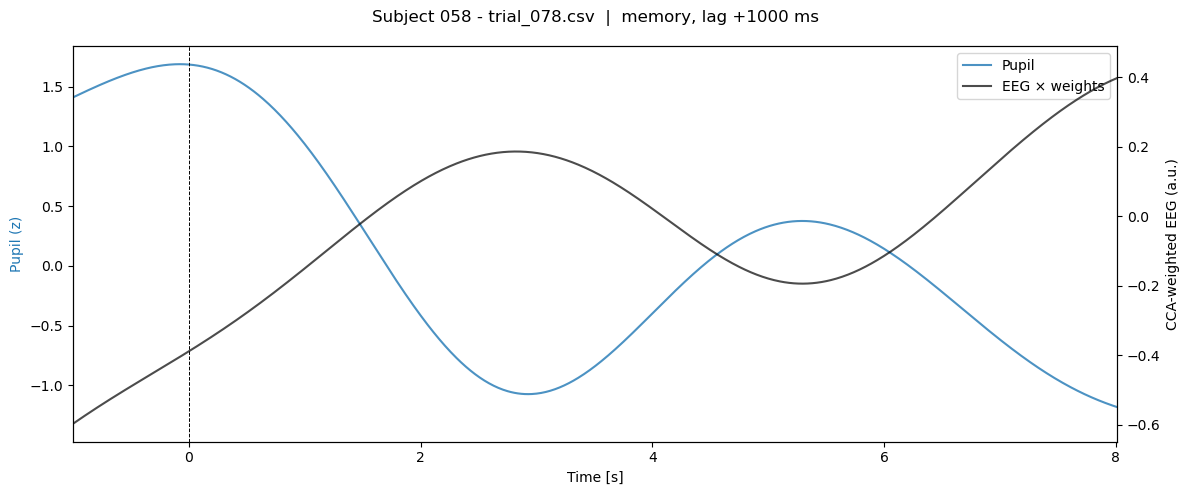

In [20]:
plot_sub      = 58
plot_trial    = "trial_078.csv"
condition     = "memory"         
lag_samples   = best_shift_by_sub.get(plot_sub, 0) // 10 

plot_trials(plot_sub, plot_trial, condition, lag_samples) # r = -0,95

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PLOTS_DIR = Path(r"C:\Users\cdd\OneDrive - Danmarks Tekniske Universitet\Spring2025\Special_course\plots_appC")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)      # creates the folder tree if it doesn't exist

def trial_average2(sub_id, trials, load, cond, lag_samples=0, channels=FRONTAL_MIDLINE):
    """
    Return average pupil (T,) and EEG (T,) for a given load.
    * trials      - list of (eeg, pupil, meta) tuples
    * load        - 5 / 9 / 13
    * lag_samples - positive = shift EEG *forward* relative to pupil
    """
    eeg_list, pupil_list = [], []

    ch_names, weights   = load_weights(plot_sub)

    if ch_names is None or weights is None:
        print(f"Missing or ambiguous weights for subject {plot_sub:03d}, cannot plot.")
    if ch_names != FRONTAL_MIDLINE:
        print(f"Warning: channel names in weights do not match expected frontal midline set.")


    for eeg, pupil, meta in trials:
        if meta["load"] != load:
            continue

        # -- project EEG and (optionally) roll for lag -------------------------
        eeg_roi = np.dot(eeg, weights)
        
        # temporal alignment ---------------------------------------------------
        if lag_samples != 0:
           eeg_roi = np.roll(eeg_roi, lag_samples)

        T = min(len(eeg_roi), len(pupil))
        eeg_list.append(eeg_roi[win])
        pupil_list.append(pupil[win, 0])

    # stack, crop to shortest, compute mean ± SEM
    if not eeg_list:                      # no trials for this load
        return None

    L = min(map(len, eeg_list))
    eeg_mat   = np.stack([e[:L] for e in eeg_list])
    pupil_mat = np.stack([p[:L] for p in pupil_list])

    eeg_avg   = eeg_mat.mean(axis=0)
    eeg_sem   = eeg_mat.std(axis=0, ddof=1) / np.sqrt(eeg_mat.shape[0])
    pupil_avg = pupil_mat.mean(axis=0)
    pupil_sem = pupil_mat.std(axis=0, ddof=1) / np.sqrt(pupil_mat.shape[0])

    t = np.arange(L) / 100.0 -1.0             # 100 Hz → seconds
    return t, (eeg_avg, eeg_sem), (pupil_avg, pupil_sem)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------ #
# ❶  Load the subject-level CCA table *once* at module import time
# ------------------------------------------------------------------ #
CCA_FILE = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\fast_slow_components\subject_level_cca_slow.csv")
CCA_DF   = pd.read_csv(CCA_FILE)        # columns: subject, condition, lag_ms, r, p-value
CCA_DF["condition"] = CCA_DF["condition"].str.lower()   # normalise to lowercase
CCA_DF.set_index(["subject", "condition"], inplace=True)

# ------------------------------------------------------------------ #
def plot_subject2(sub_id: int, loads=(5, 9, 13)):
    """
    One figure with 3 (rows = load) × 2 (cols = task) panels.
    Each panel overlays pupil and EEG-θ for a single load and task,
    and the panel title now includes the subject-specific CCA 'r'.
    """
    trials = load_all_trials(sub_id)
    mem, ctl = split_trials_by_condition(trials)

    lag       = best_shift_by_sub.get(sub_id, 0)  // 10          # samples @100 Hz
    colors    = {5: "#1f77b4", 9: "#ff7f0e", 13: "#2ca02c"}
    task_sets = [(mem, "memory"), (ctl, "control")]

    # ── look up the two r values for this subject ──────────────────
    r_memory  = float(CCA_DF.loc[(sub_id, "memory"), "r"])   if (sub_id, "memory")  in CCA_DF.index else float("nan")
    r_control = float(CCA_DF.loc[(sub_id, "control"), "r"])  if (sub_id, "control") in CCA_DF.index else float("nan")
    r_by_cond = {"memory": r_memory, "control": r_control}

    # ── make subplot grid (no shared x) ───────────────────────────
    fig, axes = plt.subplots(len(loads), 2, figsize=(12, 9), sharey="row")
    legend_handles, legend_labels = [], []

    for row, load in enumerate(loads):
        for col, (trial_set, cond) in enumerate(task_sets):
            ax = axes[row, col]

            res = trial_average2(sub_id, trial_set, load, cond, lag_samples=lag)
            if res is None:            # no data → hide the axis
                print(f"Subject {sub_id:02d} has no trials for load {load} ({cond})")
                ax.set_visible(False)
                continue

            t, (eeg_avg, eeg_sem), (pup_avg, pup_sem) = res
            # ─────────── z-score each series ──────────────────────────
            # (mean-remove, divide by SD; adjust SEM by the same SD)
            p_mean, p_std = pup_avg.mean(), pup_avg.std(ddof=0)
            e_mean, e_std = eeg_avg.mean(), eeg_avg.std(ddof=0)

            pup_avg = (pup_avg - p_mean) / p_std
            pup_sem = pup_sem / p_std

            eeg_avg = (eeg_avg - e_mean) / e_std
            eeg_sem = eeg_sem / e_std


            # pupil ────────────────────────────────────────────────
            ax.plot(t, pup_avg, color=colors[load], label="Pupil")
            ax.fill_between(t, pup_avg - pup_sem, pup_avg + pup_sem, color=colors[load], alpha=.25)

            # EEG θ ────────────────────────────────────────────────
            ax_r = ax.twinx()
            ax_r.plot(t, eeg_avg, color="black", lw=1.2, label="θ")
            ax_r.fill_between(t, eeg_avg - eeg_sem, eeg_avg + eeg_sem, color="black", alpha=.15)

            # cosmetics ───────────────────────────────────────────
            ax.set_xlim(-1, t[-100])
            ax.set_yticks([]); ax_r.set_yticks([])
            ax.axvline(0, ls="--", c="k", lw=.7)

            if col == 0:
                ax.set_ylabel(f"Load {load:02d}")
            if row == 0:
                # add r to title
                r_val = r_by_cond[cond]
                ax.set_title(f"{cond.capitalize()}  (r = {r_val:.3f})")

            if not legend_handles:
                legend_handles += ax.get_lines() + ax_r.get_lines()
                legend_labels  += [h.get_label() for h in legend_handles]

    axes[0, 0].legend(legend_handles, legend_labels,
                      loc="upper right", frameon=False)

    fig.suptitle(f"Subject {sub_id:03d}   |   lag = {lag/100:.2f} s")
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    # ── SAVE the figure ───────────────────────────────────────────
    # ── SAVE instead of show ────────────────────────────────────────
    fname = PLOTS_DIR / f"s{sub_id:02d}.png"      #  e.g.  s05.png
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close(fig)    


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\core\_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


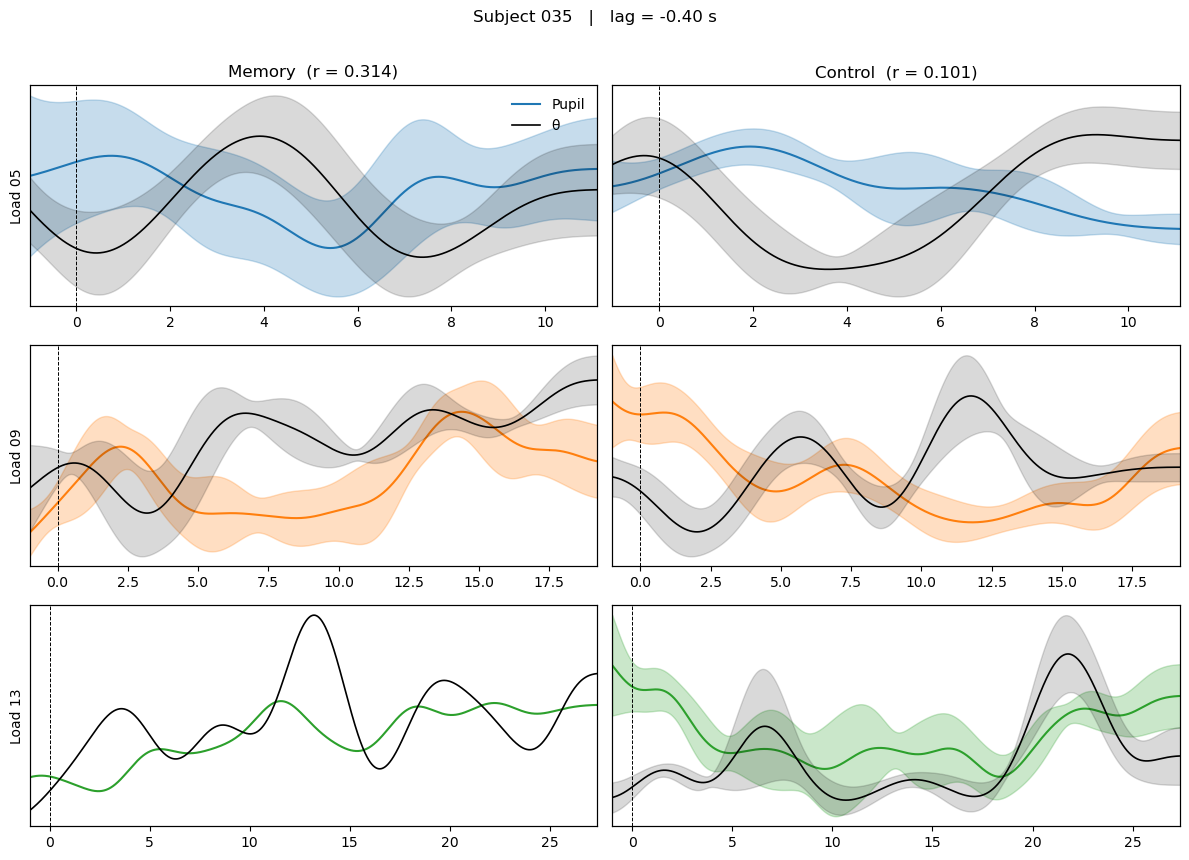

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


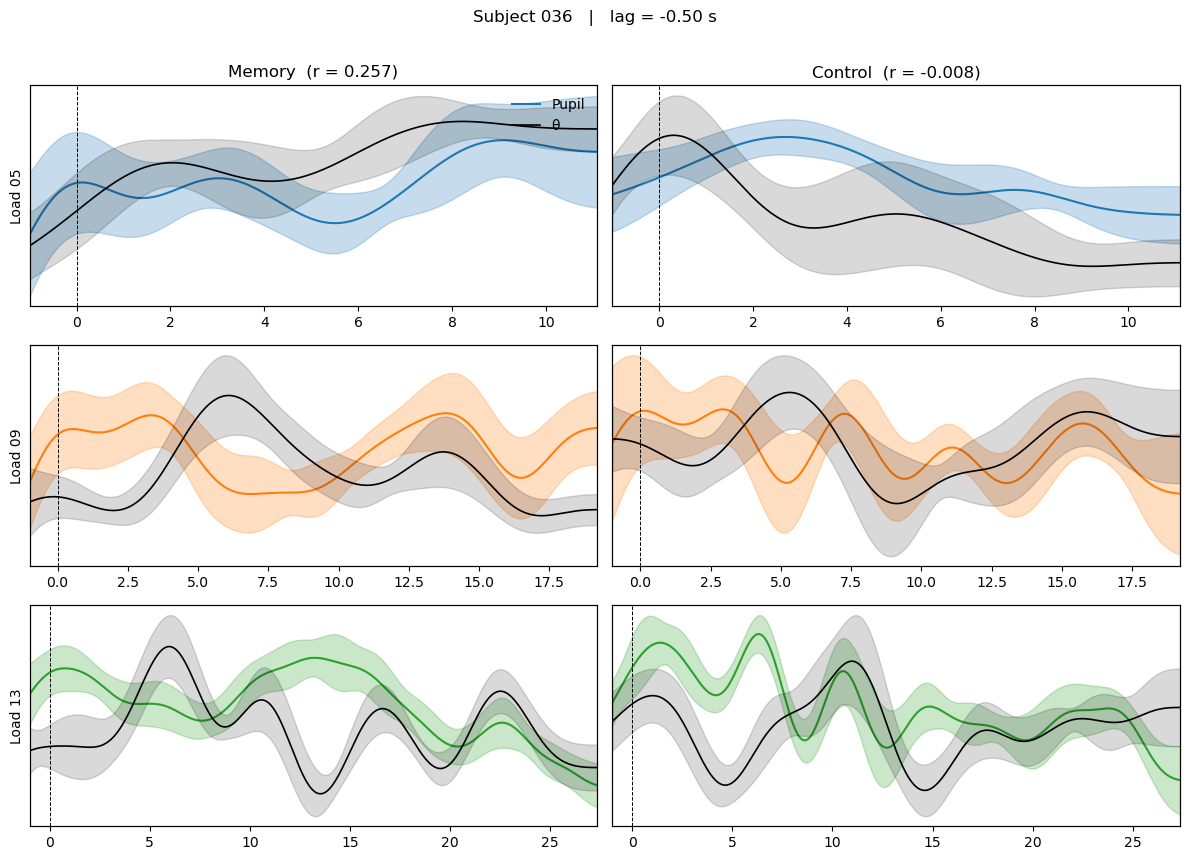

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


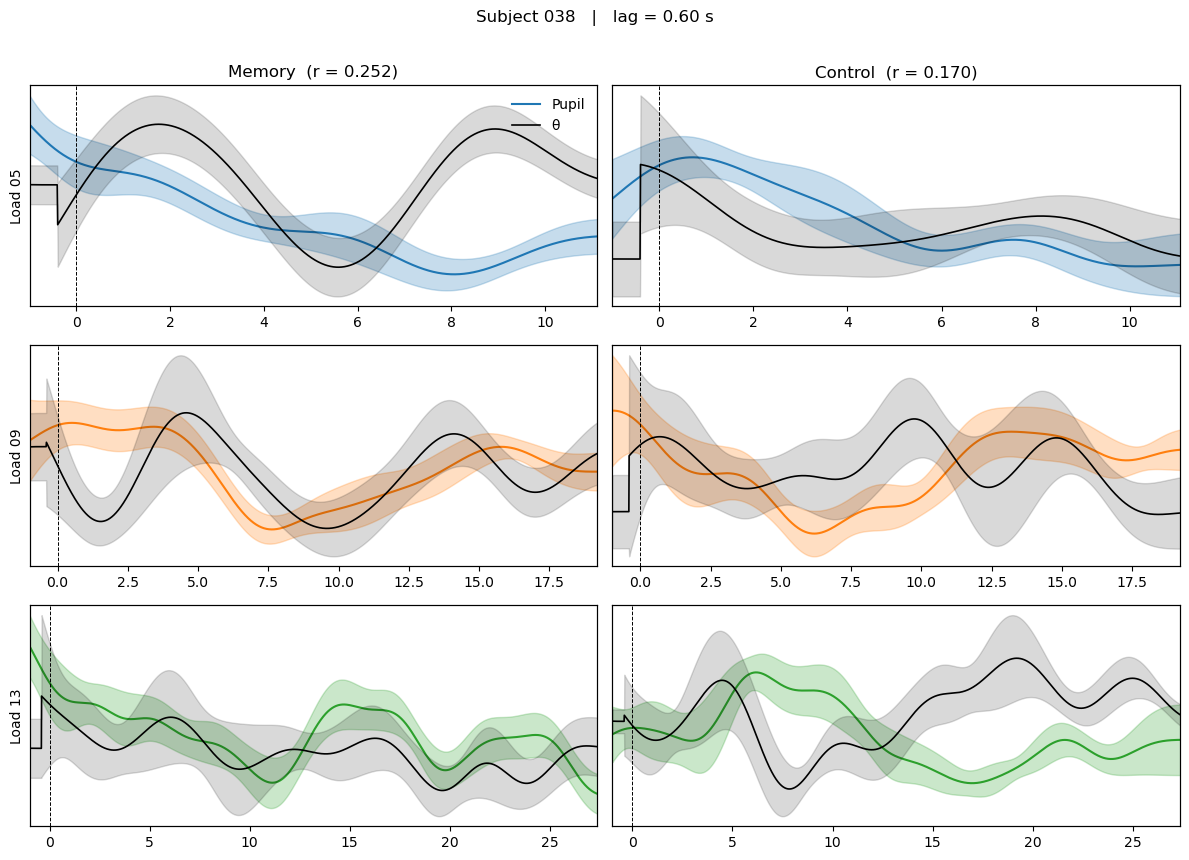

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


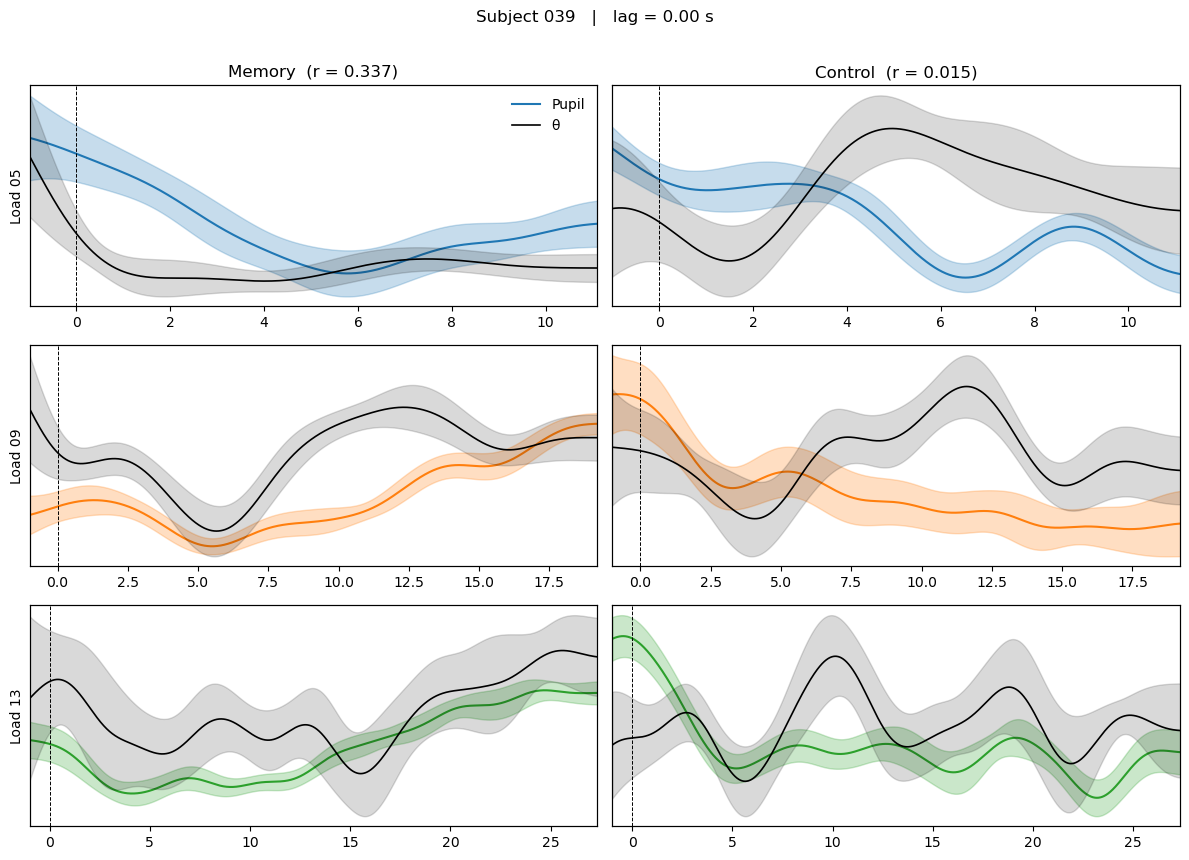

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


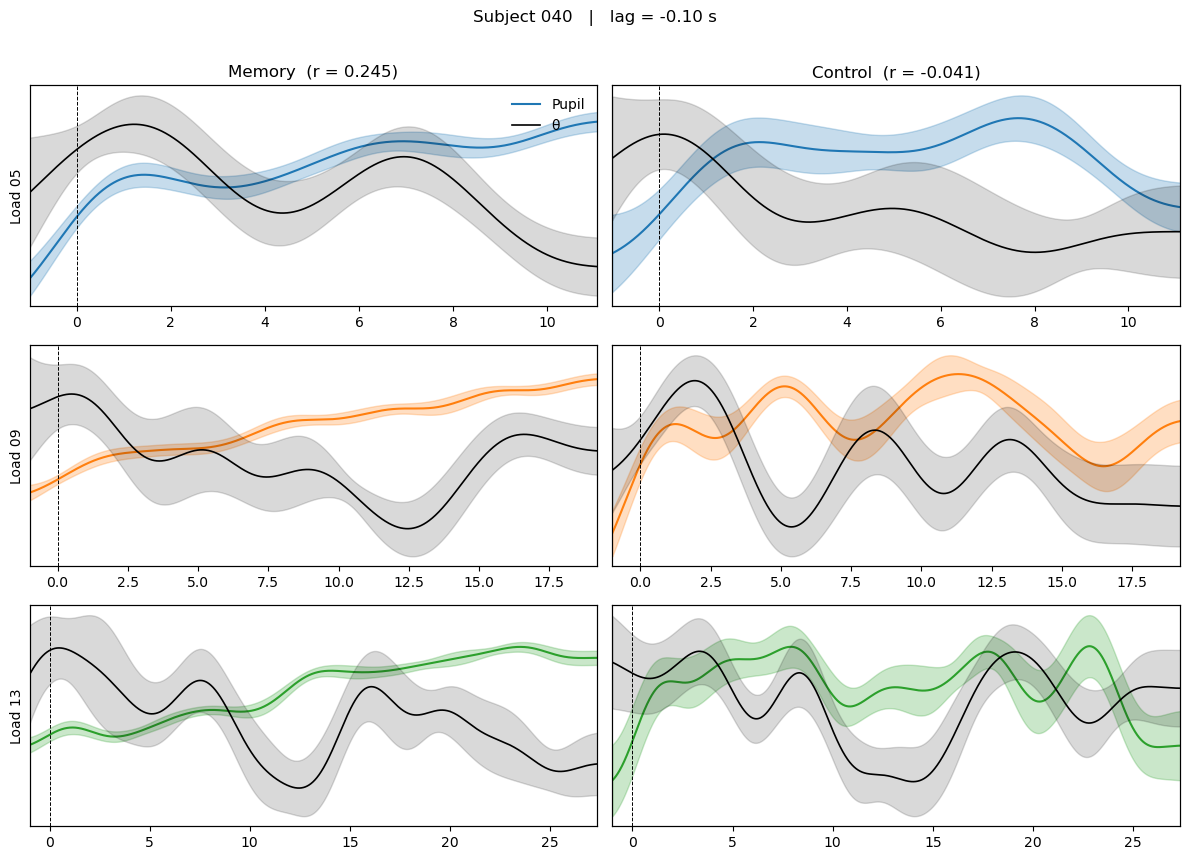

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


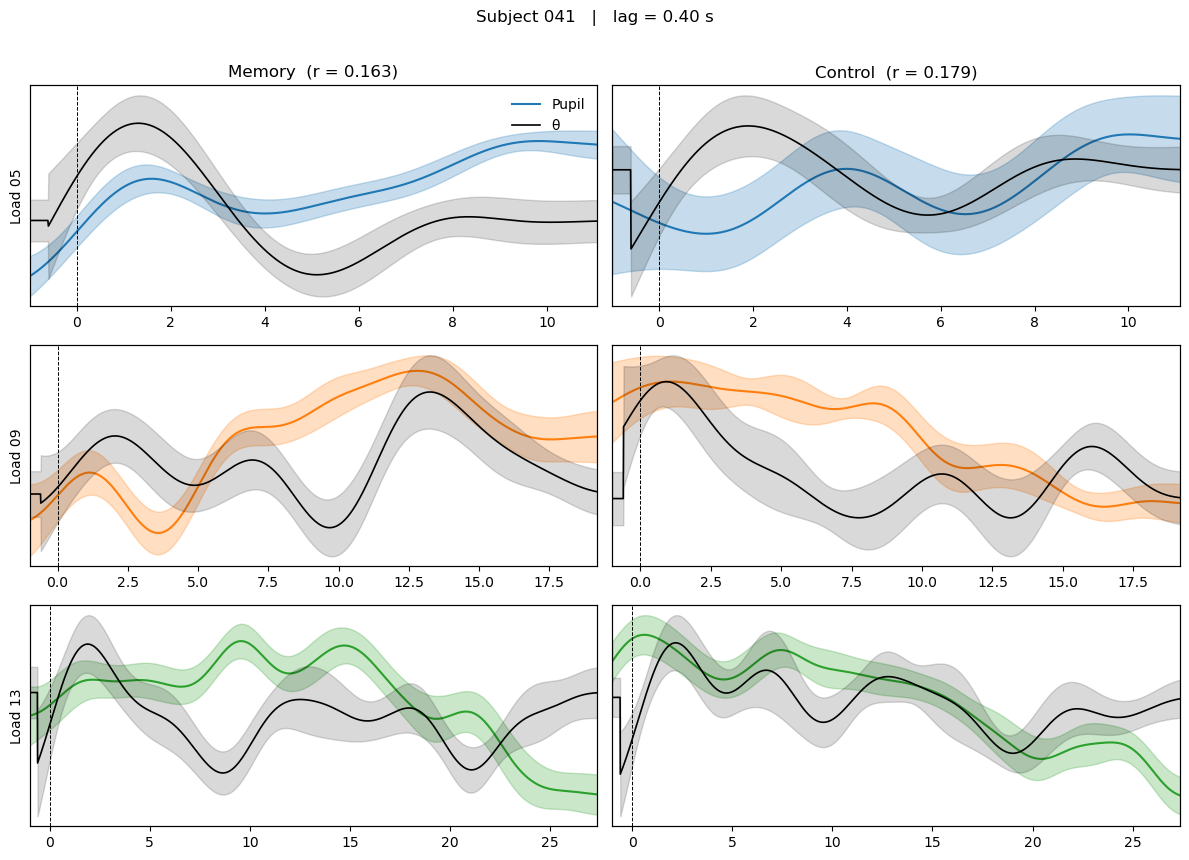

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


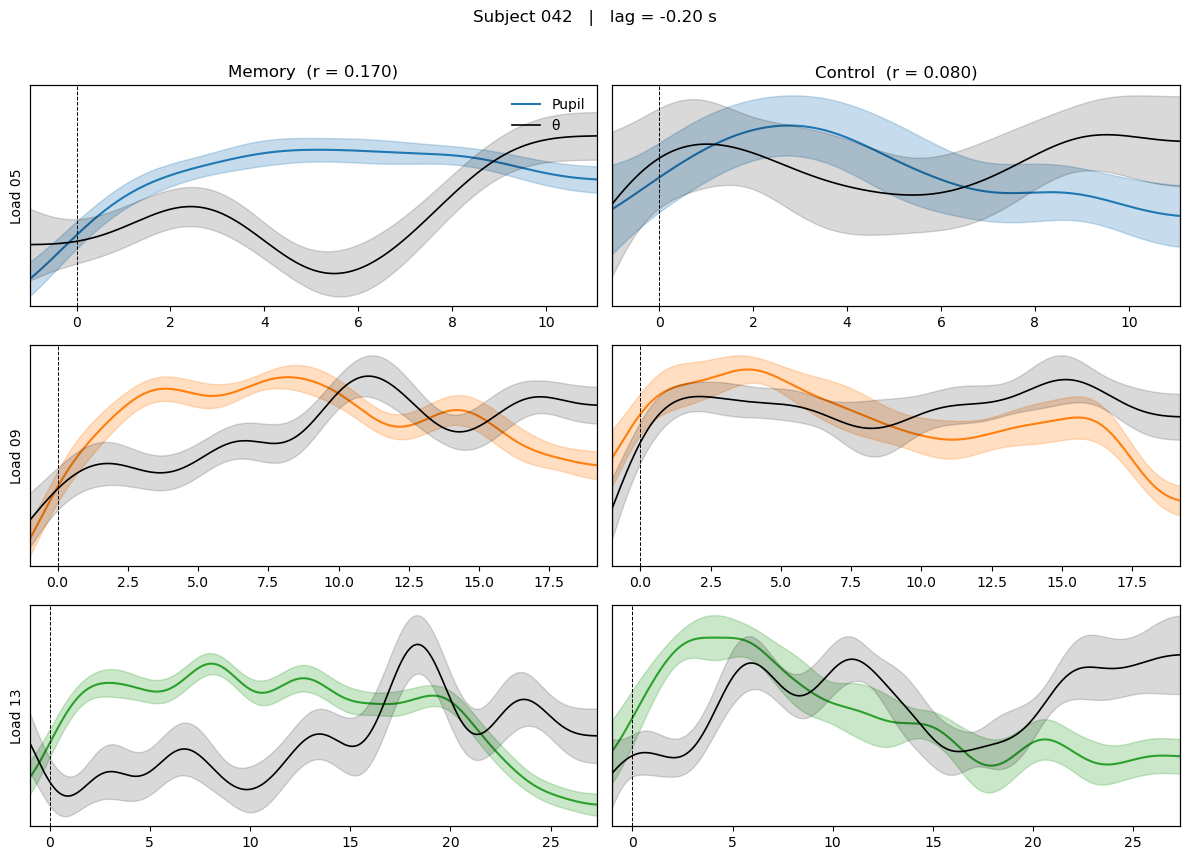

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


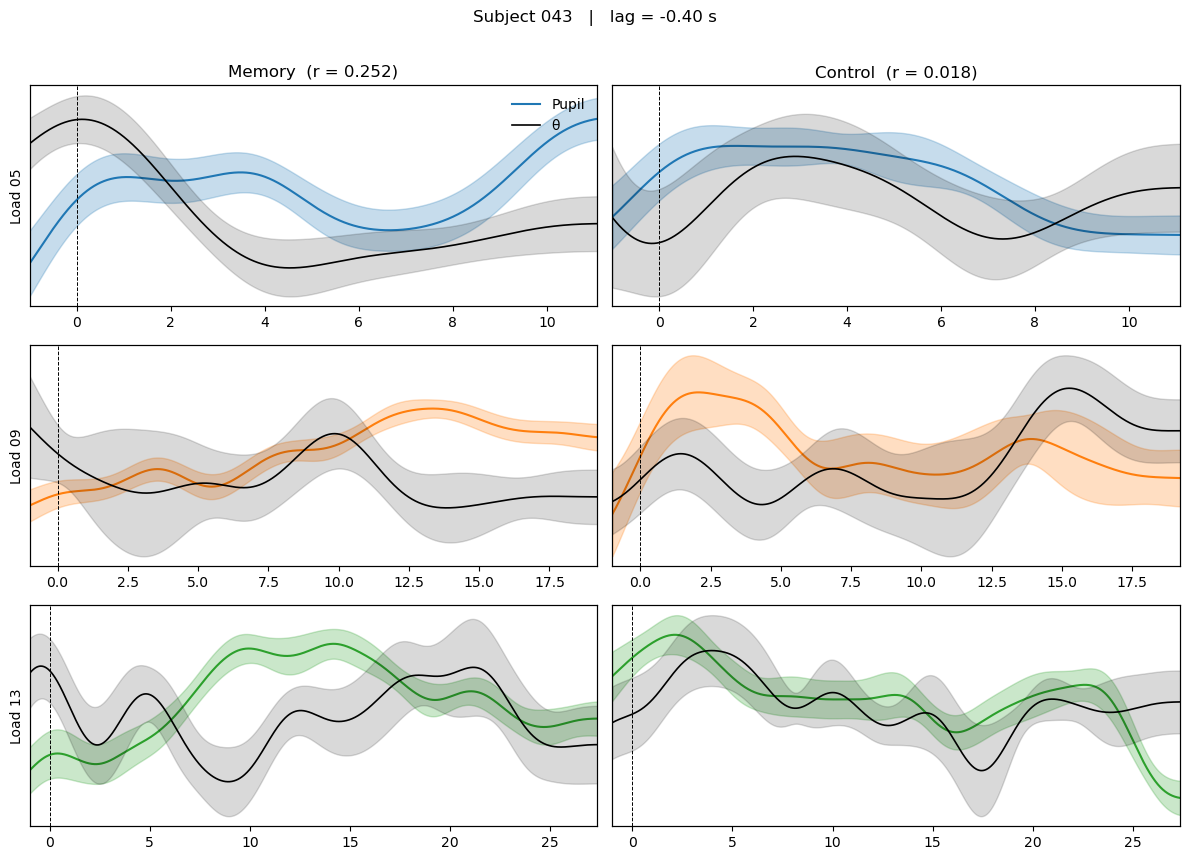

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


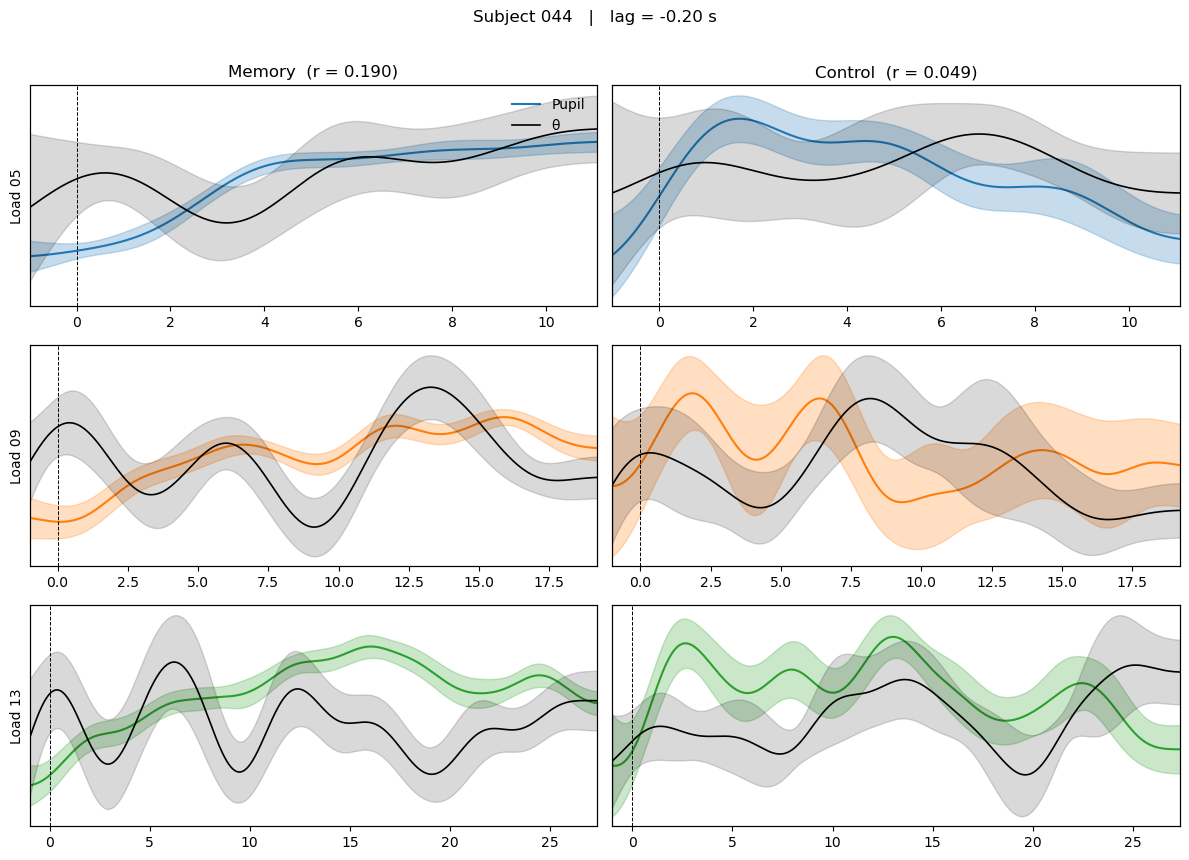

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


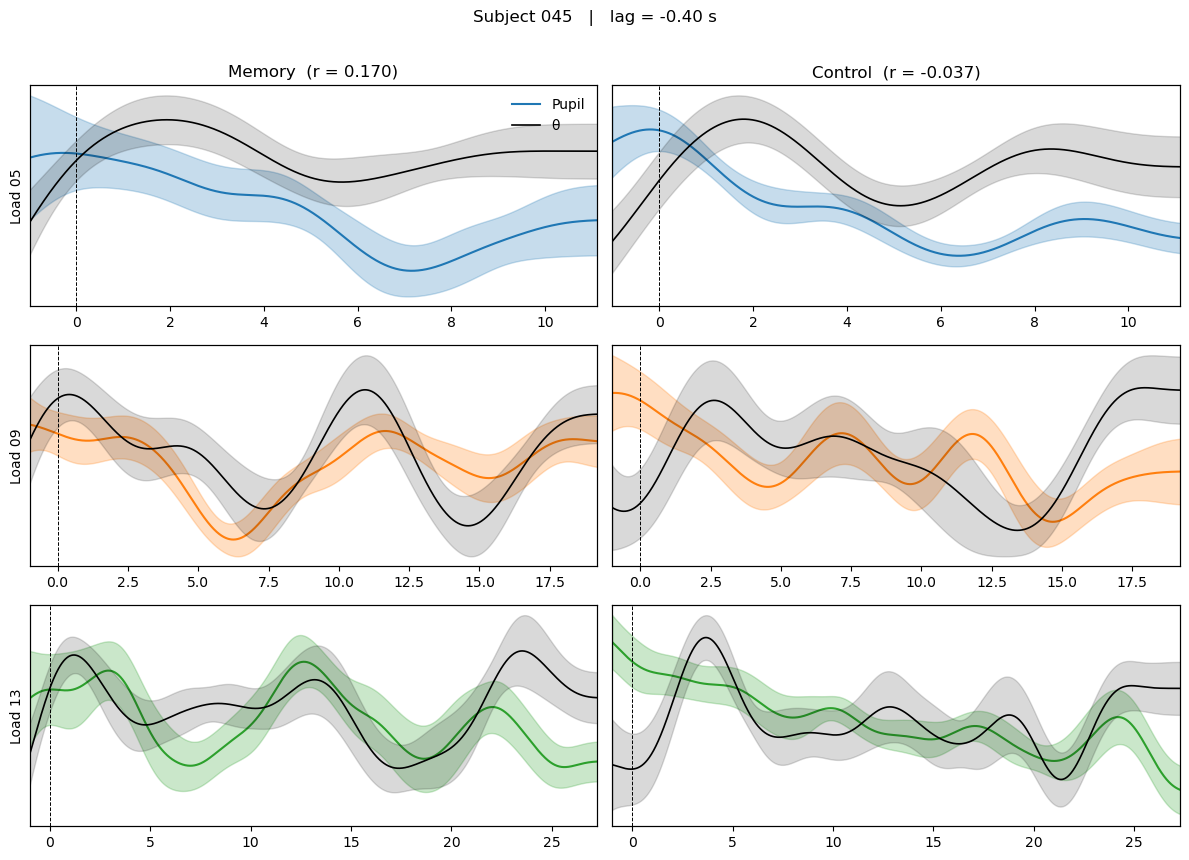

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\numpy\core\_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


Subject 46 has no trials for load 9 (memory)


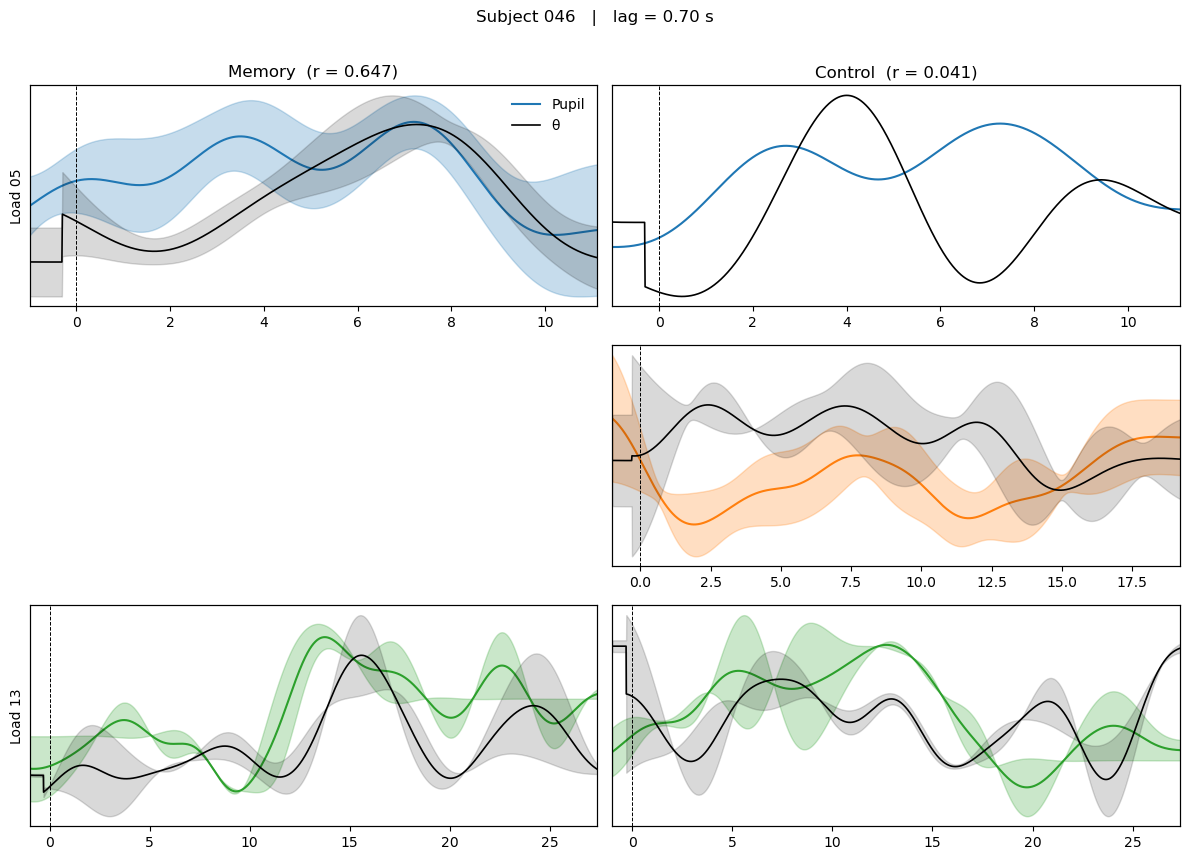

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


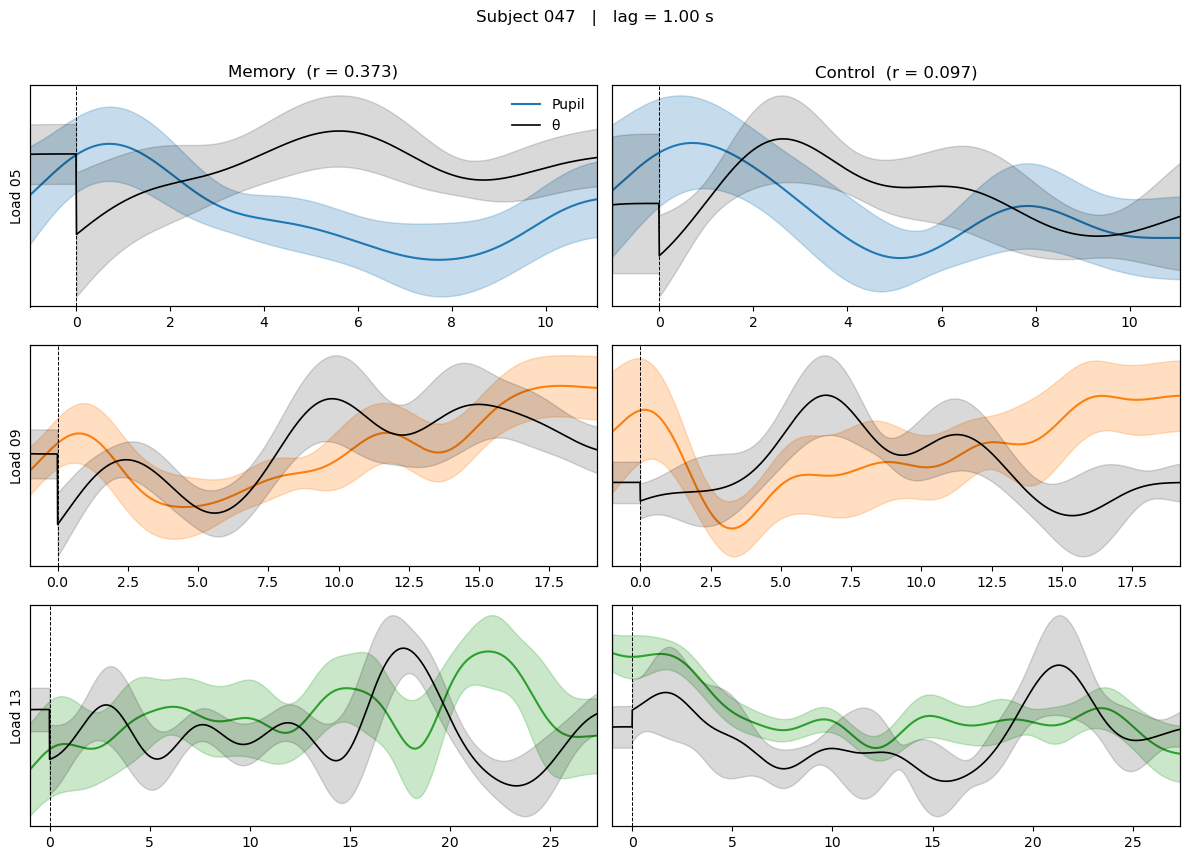

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


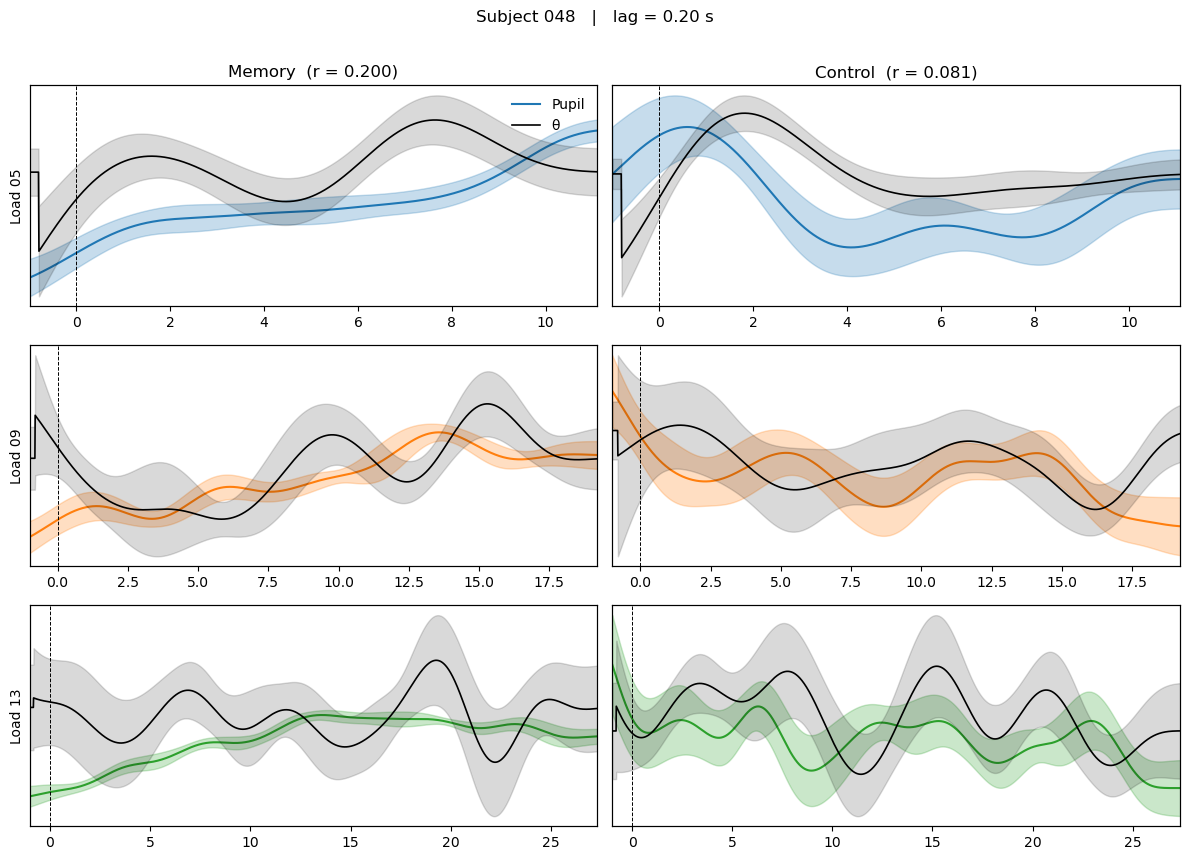

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


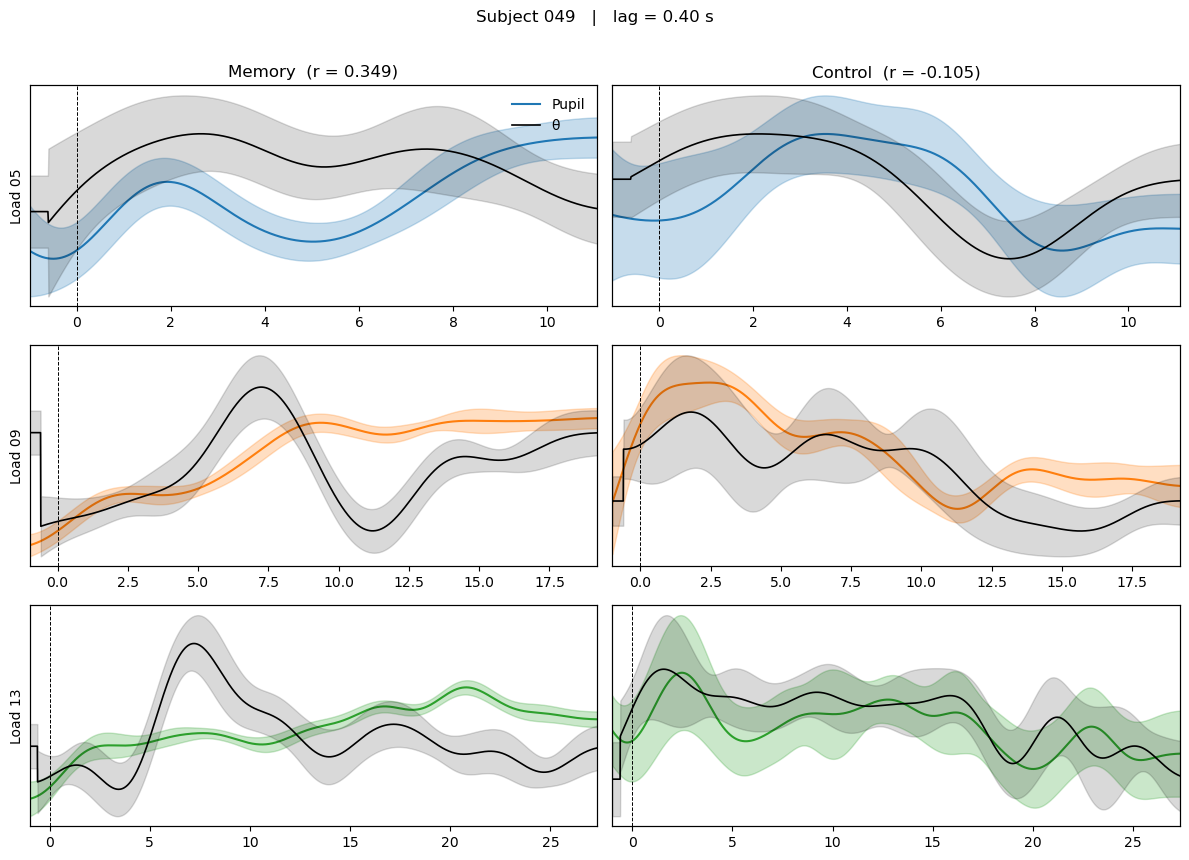

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


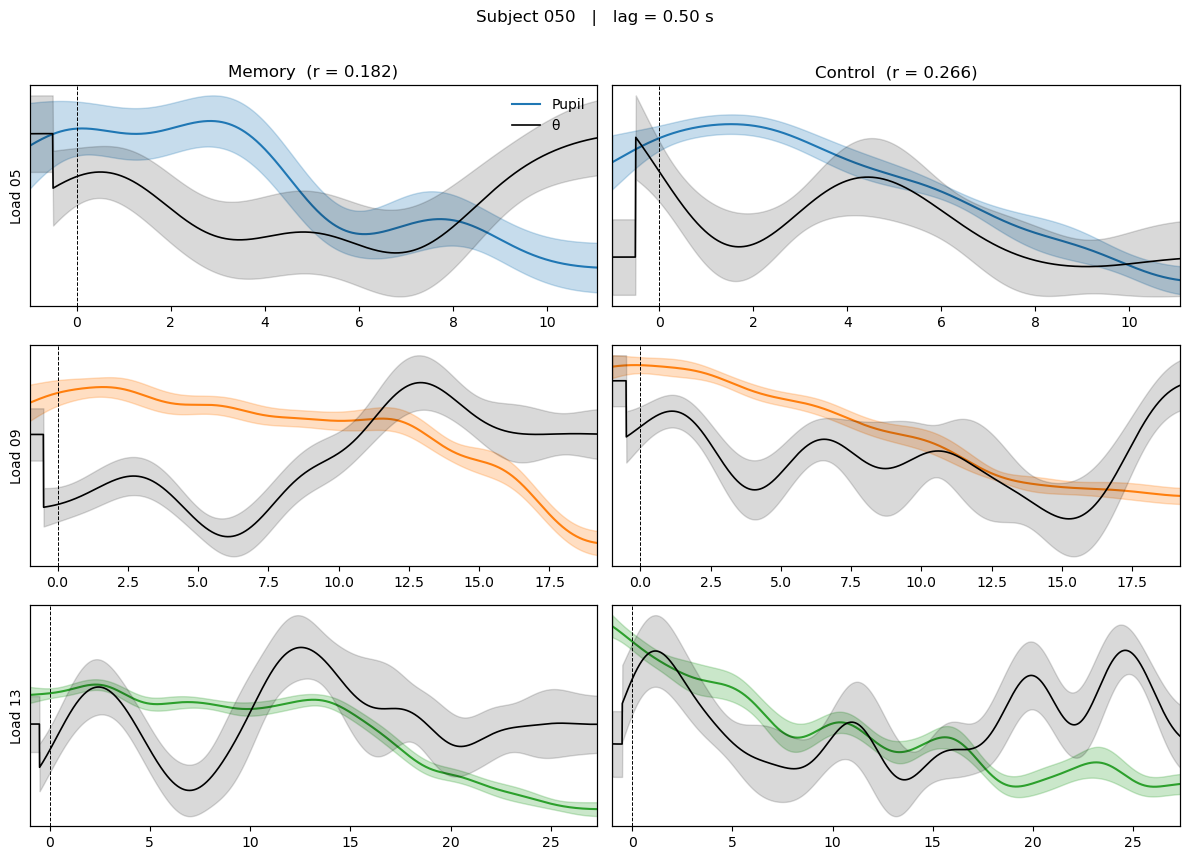

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


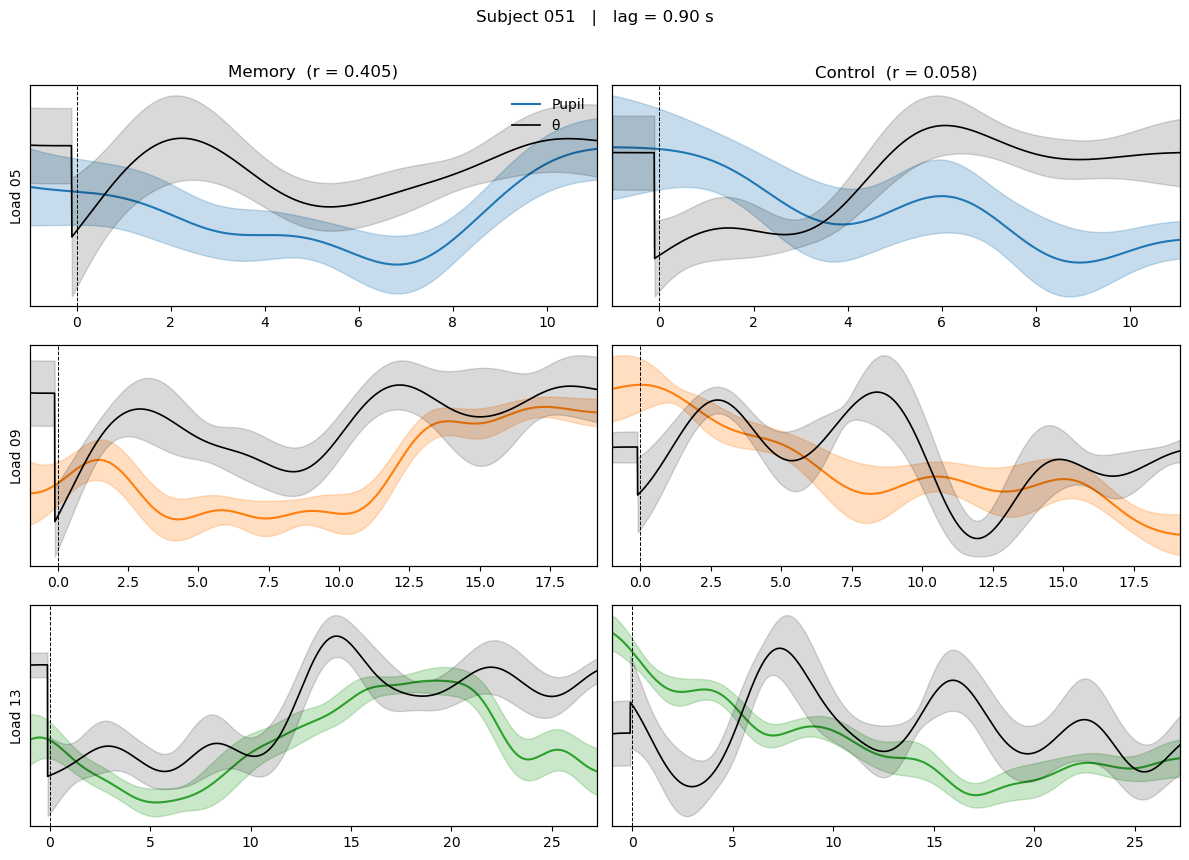

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


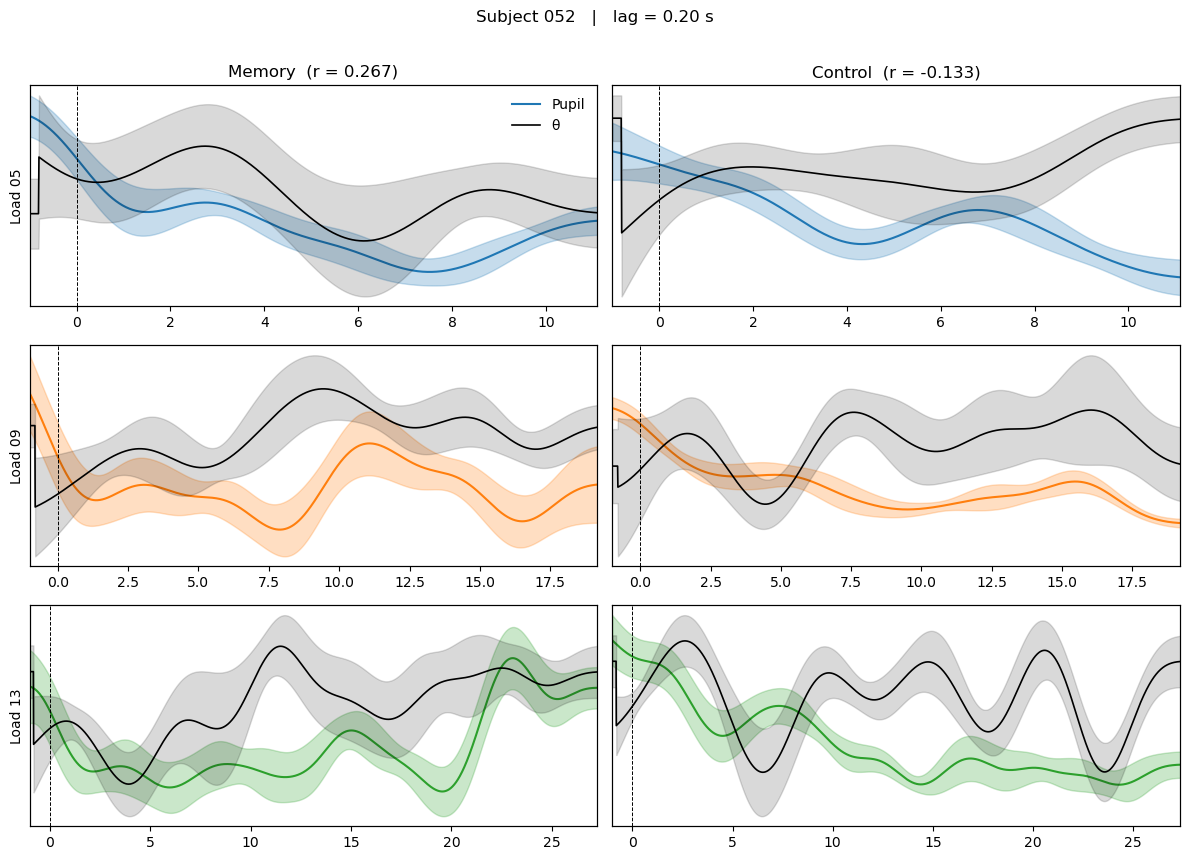

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


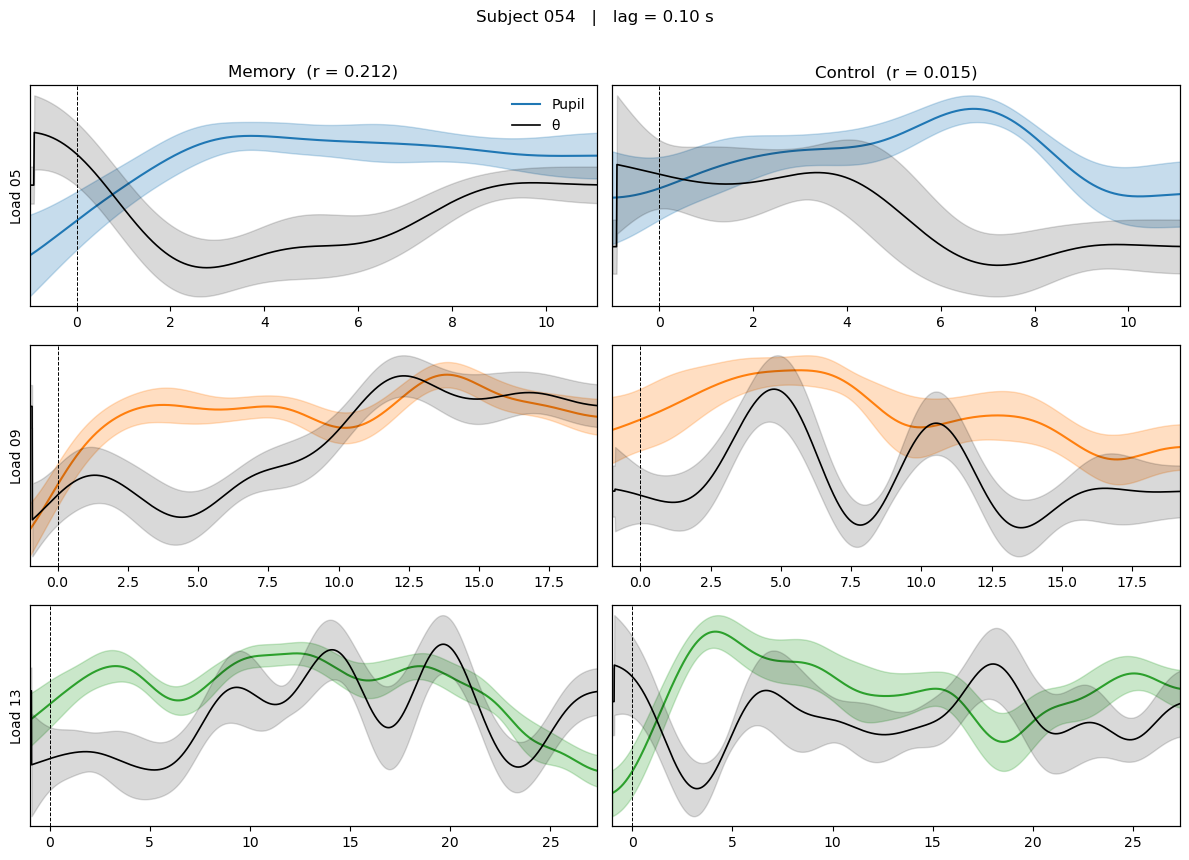

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


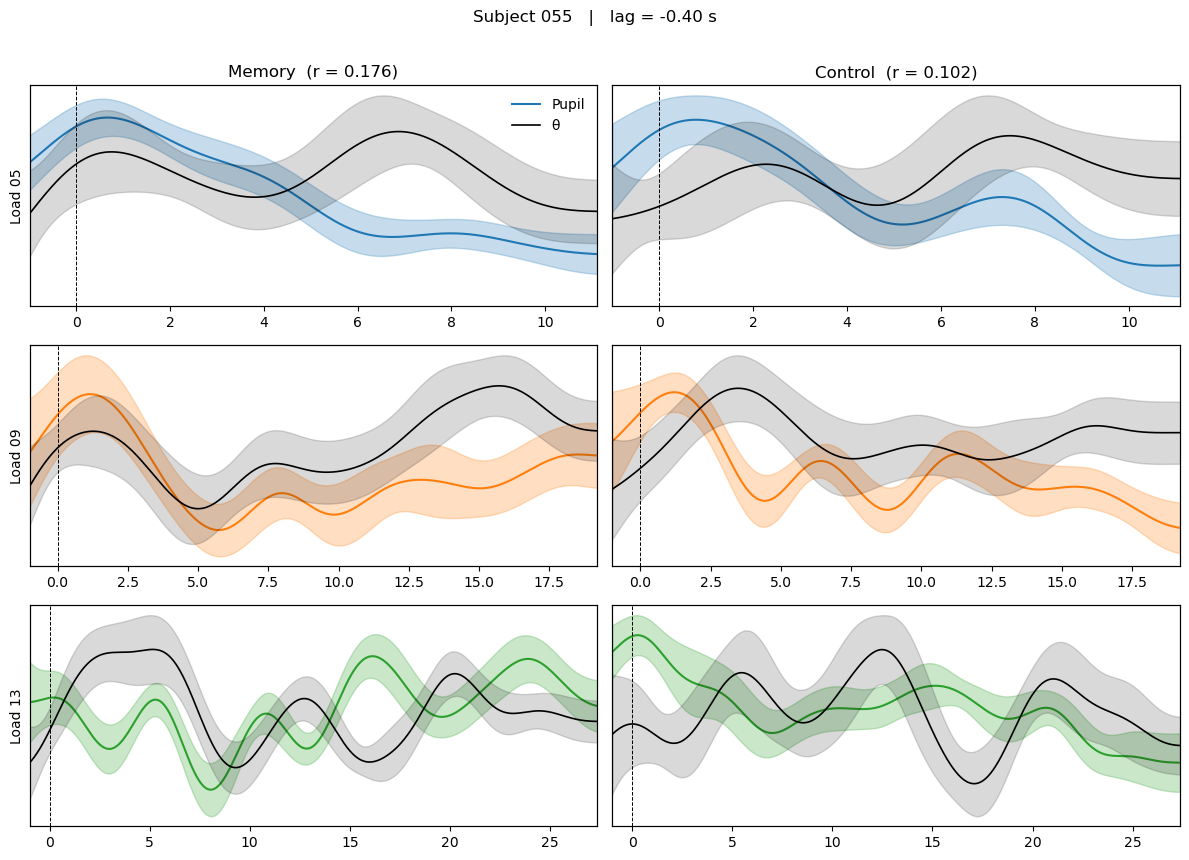

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


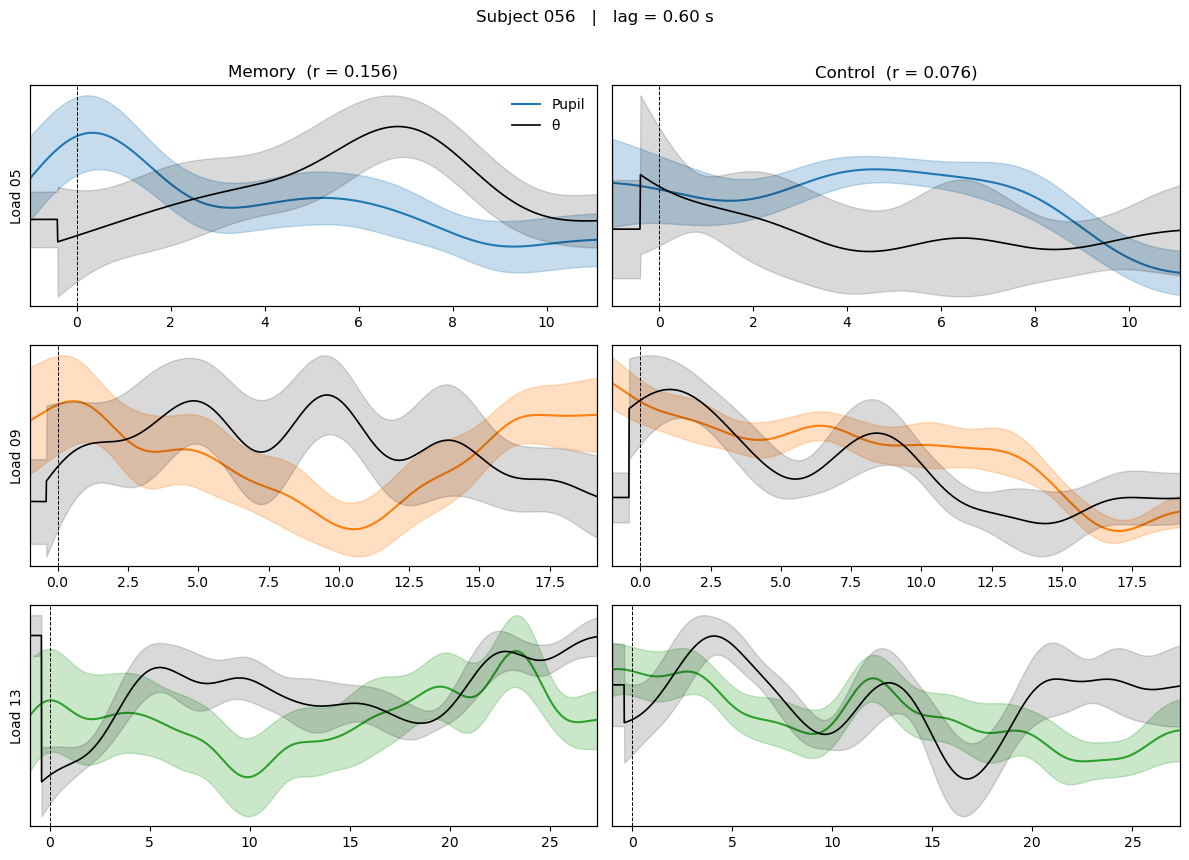

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


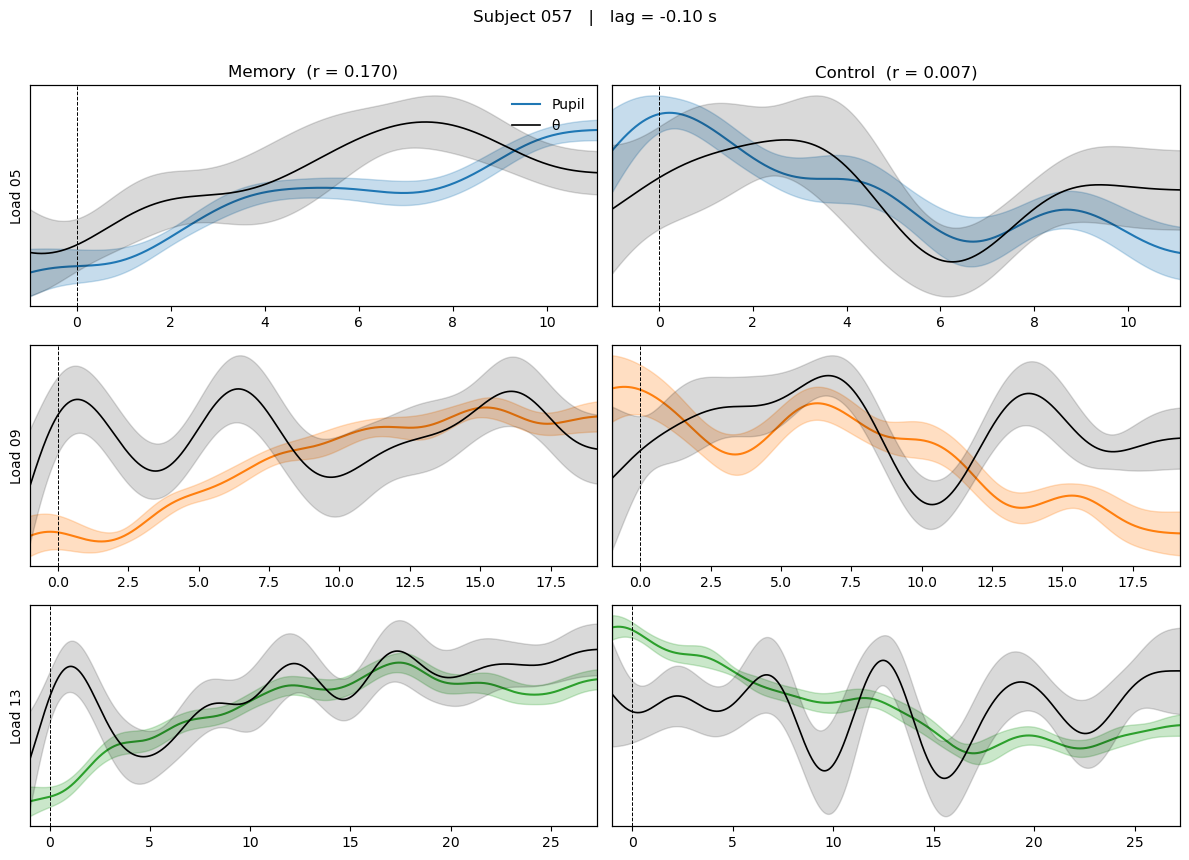

C:\Users\cdd\AppData\Local\Temp\ipykernel_31168\3924123886.py:138: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axes[0, 0].legend(legend_handles, legend_labels,


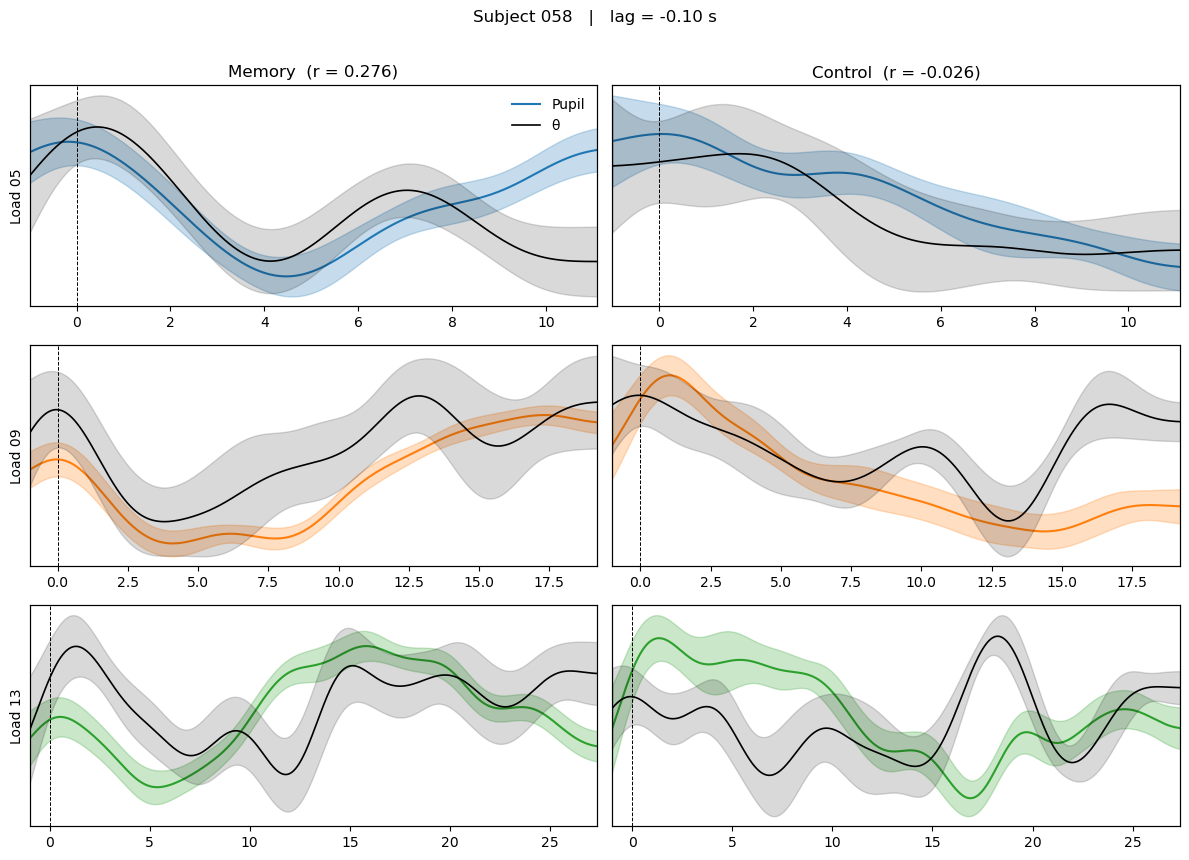

In [39]:
for subj in SUBJECTS:   # or any custom list
    plot_subject2(subj)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def _project_and_align(eeg, pupil, weights, lag_samples=0, win=None):
    """Return aligned 1D eeg_roi, pupil_1d for one trial (optionally cropped)."""
    eeg_roi = np.dot(eeg, weights)            # (T,C)·(C,) → (T,)
    if lag_samples:
        eeg_roi = np.roll(eeg_roi, lag_samples)

    pupil = np.asarray(pupil)
    pupil_1d = pupil[:, 0] if pupil.ndim == 2 else pupil

    T = min(len(eeg_roi), len(pupil_1d))
    eeg_roi = eeg_roi[:T]
    pupil_1d = pupil_1d[:T]

    if win is not None:
        w = win if isinstance(win, slice) else slice(win[0], win[1])
        eeg_roi = eeg_roi[w]
        pupil_1d = pupil_1d[w]

    return eeg_roi, pupil_1d

def _trialwise_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    return (x - mu) / (sd if sd > 0 else 1.0)

def plot_grand_average_trials(
        subjects=None, loads=(5,9,13), z_per_trial=True,
        save_name="grand_average_trials.png", win=None
    ):
    """
    Pool *all trials* across all subjects for each (condition,load),
    then compute mean±SEM across trials (subjects with more trials weigh more).
    """
    # subjects default: infer from your CCA_DF or fallback to best_shift_by_sub keys
    if subjects is None:
        try:
            subjects = sorted({int(s) for (s, _) in CCA_DF.index})
        except Exception:
            subjects = sorted(best_shift_by_sub.keys()) if 'best_shift_by_sub' in globals() else []
    if not subjects:
        print("No subjects available.")
        return

    colors = {5: "#1f77b4", 9: "#ff7f0e", 13: "#2ca02c"}
    tasks  = ["memory", "control"]

    # For each panel we will collect lists of trial arrays
    panel_trials = { (cond, load): {"eeg": [], "pupil": []}
                     for cond in tasks for load in loads }

    # --- collect trials ---
    for sub in subjects:
        # per-subject pieces
        print(f"Loading subject {sub}...")
        try:
            trials = load_all_trials(sub)
        except Exception as e:
            print(f"Skipping subject {sub}: load_all_trials failed ({e})")
            continue

        try:
            ch_names, weights = load_weights(sub)
            if weights is None:
                print(f"Skipping subject {sub}: no weights.")
                continue
        except Exception as e:
            print(f"Skipping subject {sub}: load_weights failed ({e})")
            continue

        lag_ms = best_shift_by_sub.get(sub, 0) if 'best_shift_by_sub' in globals() else 0
        if lag_ms == 0: print(f"Subject {sub}: no lag")
        
        lag_samples = int(round(lag_ms / 10.0))   # 100 Hz → 10 ms per sample

        mem, ctl = split_trials_by_condition(trials)
        by_cond = {"memory": mem, "control": ctl}

        for cond in tasks:
            for eeg, pupil, meta in by_cond[cond]:
                L = meta.get("load", None)
                if L not in loads: 
                    continue

                eeg_roi, pupil_1d = _project_and_align(eeg, pupil, weights, lag_samples, win)

                if z_per_trial:
                    eeg_roi  = _trialwise_z(eeg_roi)
                    pupil_1d = _trialwise_z(pupil_1d)

                panel_trials[(cond, L)]["eeg"].append(eeg_roi)
                panel_trials[(cond, L)]["pupil"].append(pupil_1d)

    # --- plot 3×2 grid ---
    fig, axes = plt.subplots(len(loads), 2, figsize=(12, 9), sharey="row")
    legend_handles, legend_labels = [], []

    for r, load in enumerate(loads):
        for c, cond in enumerate(tasks):
            ax = axes[r, c]
            eeg_list  = panel_trials[(cond, load)]["eeg"]
            pup_list  = panel_trials[(cond, load)]["pupil"]

            if not eeg_list:
                ax.set_visible(False)
                continue

            # align all trials to the shortest length for this panel
            Lmin = min(map(len, eeg_list + pup_list))
            eeg_stack = np.stack([e[:Lmin] for e in eeg_list], axis=0)  # (Ntrials, L)
            pup_stack = np.stack([p[:Lmin] for p in pup_list], axis=0)

            # grand mean ± SEM across trials
            eeg_mu  = eeg_stack.mean(0)
            eeg_sem = eeg_stack.std(0, ddof=1) / np.sqrt(eeg_stack.shape[0])

            pup_mu  = pup_stack.mean(0)
            pup_sem = pup_stack.std(0, ddof=1) / np.sqrt(pup_stack.shape[0])

            # time axis (assumes 100 Hz and -1s start like your subject plots)
            t = np.arange(Lmin) / 100.0 - 1.0

            ln1, = ax.plot(t, pup_mu, color=colors[load], label="Pupil")
            ax.fill_between(t, pup_mu - pup_sem, pup_mu + pup_sem, color=colors[load], alpha=.25)

            axr = ax.twinx()
            ln2, = axr.plot(t, eeg_mu, color="black", lw=1.2, label="θ")
            axr.fill_between(t, eeg_mu - eeg_sem, eeg_mu + eeg_sem, color="black", alpha=.15)

            ax.set_xlim(-1, t[-1])
            ax.set_yticks([]); axr.set_yticks([])
            ax.axvline(0, ls="--", c="k", lw=.7)

            if c == 0:
                ax.set_ylabel(f"Load {load:02d}")
            if r == 0:
                n_tr = eeg_stack.shape[0]
                ax.set_title(f"{cond.capitalize()}  (N trials = {n_tr})")

            if not legend_handles:
                legend_handles.extend([ln1, ln2])
                legend_labels.extend(["Pupil", "θ"])

    axes[0, 0].legend(legend_handles, legend_labels, loc="upper right", frameon=False)
    total_trials = sum(len(panel_trials[k]["eeg"]) for k in panel_trials)
    fig.suptitle(f"Grand average across trials (total N={total_trials}, z_per_trial={z_per_trial})")
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])

    out_path = PLOTS_DIR / save_name
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")


In [11]:
plot_grand_average_trials()

Loading subject 33...
Loading subject 34...
Loading subject 35...
Loading subject 36...
Loading subject 38...
Loading subject 39...
Loading subject 40...
Loading subject 41...
Loading subject 42...
Loading subject 43...
Loading subject 44...
Loading subject 45...
Loading subject 46...
Loading subject 47...
Loading subject 48...
Loading subject 49...
Loading subject 50...
Loading subject 51...
Loading subject 52...
Loading subject 54...
Loading subject 55...
Loading subject 56...
Loading subject 57...
Loading subject 58...
Loading subject 59...
Loading subject 60...
Loading subject 62...
Loading subject 63...
Loading subject 64...
Loading subject 65...
Loading subject 67...
Loading subject 68...
Loading subject 69...
Loading subject 70...
Loading subject 71...
Loading subject 72...
Loading subject 73...
Subject 73: no lag
Loading subject 74...
Loading subject 75...
Loading subject 76...
Loading subject 77...
Loading subject 79...
Loading subject 80...
Loading subject 81...
Loading subje